In [15]:
#ARIMA

!pip install yfinance pmdarima arch plotly -q

import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pmdarima import auto_arima
from arch import arch_model

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, zivot_andrews
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [16]:
START_D = '2023-01-01'
END_D   = '2026-03-20'

def download_and_clean(ticker, start=None, end=None, period=None, interval='1d'):
    if period:
        df = yf.download(ticker, period=period, interval=interval, progress=False, auto_adjust=True)
    else:
        df = yf.download(ticker, start=start, end=end, interval=interval, progress=False, auto_adjust=True)
    if df.empty:
        raise ValueError(f"Sin datos para {ticker} en intervalo {interval}.")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)
    return df[['Open','High','Low','Close','Volume']].copy()

# Diario
bac_d = download_and_clean('BAC', start=START_D, end=END_D)
khc_d = download_and_clean('KHC', start=START_D, end=END_D)
print(f"BAC diario:  {len(bac_d)} registros  |  {bac_d.index[0].date()} → {bac_d.index[-1].date()}")
print(f"KHC diario:  {len(khc_d)} registros  |  {khc_d.index[0].date()} → {khc_d.index[-1].date()}")

# 5 minutos (últimos 30 días)
bac_5m = download_and_clean('BAC', period='30d', interval='5m')
print(f"BAC 5min:    {len(bac_5m)} registros")

# 1 hora (últimos 60 días)
bac_1h = download_and_clean('BAC', period='60d', interval='1h')
print(f"BAC 1h:      {len(bac_1h)} registros")

print("\n✅ Datos descargados correctamente.")

BAC diario:  805 registros  |  2023-01-03 → 2026-03-19
KHC diario:  805 registros  |  2023-01-03 → 2026-03-19
BAC 5min:    2303 registros
BAC 1h:      413 registros

✅ Datos descargados correctamente.


In [17]:
fig_candle = go.Figure(data=go.Candlestick(
    x=bac_d.index,
    open=bac_d['Open'], high=bac_d['High'],
    low=bac_d['Low'],   close=bac_d['Close'],
    name='BAC'
))
fig_candle.update_layout(
    title='BAC — Precio Histórico Diario (2023-2026)',
    xaxis_rangeslider_visible=False,
    xaxis_title='Fecha', yaxis_title='Precio (USD)'
)
fig_candle.show()

In [18]:
def test_adf(series, name):
    r = adfuller(series.dropna(), autolag='AIC')
    print(f"  ADF  | stat={r[0]:.4f}  p={r[1]:.4f}  {'✅ Estacionaria' if r[1]<0.05 else '❌ No estacionaria'}")
    return r

def test_kpss(series, name):
    r = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"  KPSS | stat={r[0]:.4f}  p={r[1]:.4f}  {'✅ Estacionaria' if r[1]>=0.05 else '❌ No estacionaria'}")
    return r

def test_pp(series, name):
    r = adfuller(series.dropna(), regression='c', autolag='AIC')
    print(f"  PP   | stat={r[0]:.4f}  p={r[1]:.4f}  (aprox. Phillips-Perron)")
    return r

def test_za(series, name):
    r = zivot_andrews(series.dropna(), regression='c', autolag='AIC')
    print(f"  ZA   | stat={r[0]:.4f}  p={r[1]:.4f}  quiebre en índice {r[3]}")
    return r

for ticker_name, series in [('BAC', bac_d['Close']), ('KHC', khc_d['Close'])]:
    print(f"\n{'='*50}")
    print(f" Pruebas para: {ticker_name} — Precio de cierre")
    print(f"{'='*50}")
    test_adf(series, ticker_name)
    test_kpss(series, ticker_name)
    test_pp(series, ticker_name)
    test_za(series, ticker_name)

print("\n--- Primeras diferencias (rendimientos) ---")
for ticker_name, series in [('BAC', bac_d['Close'].diff().dropna()),
                              ('KHC', khc_d['Close'].diff().dropna())]:
    print(f"\n{ticker_name} — Primera diferencia:")
    test_adf(series, ticker_name)
    test_kpss(series, ticker_name)


 Pruebas para: BAC — Precio de cierre
  ADF  | stat=-0.9618  p=0.7669  ❌ No estacionaria
  KPSS | stat=3.9109  p=0.0100  ❌ No estacionaria
  PP   | stat=-0.9618  p=0.7669  (aprox. Phillips-Perron)
  ZA   | stat=-3.3782  p=0.7538  quiebre en índice 1

 Pruebas para: KHC — Precio de cierre
  ADF  | stat=-1.2529  p=0.6504  ❌ No estacionaria
  KPSS | stat=3.2950  p=0.0100  ❌ No estacionaria
  PP   | stat=-1.2529  p=0.6504  (aprox. Phillips-Perron)
  ZA   | stat=-5.1909  p=0.0153  quiebre en índice 0

--- Primeras diferencias (rendimientos) ---

BAC — Primera diferencia:
  ADF  | stat=-26.0531  p=0.0000  ✅ Estacionaria
  KPSS | stat=0.0743  p=0.1000  ✅ Estacionaria

KHC — Primera diferencia:
  ADF  | stat=-29.5968  p=0.0000  ✅ Estacionaria
  KPSS | stat=0.0554  p=0.1000  ✅ Estacionaria


Prueba de cointegración de Johansen — BAC vs KHC
         Estadístico traza     VC 90%     VC 95%     VC 99%
r≤0                8.1528    13.4294    15.4943    19.9349  — Sin cointegración
r≤1                0.3941     2.7055     3.8415     6.6349  — Sin cointegración


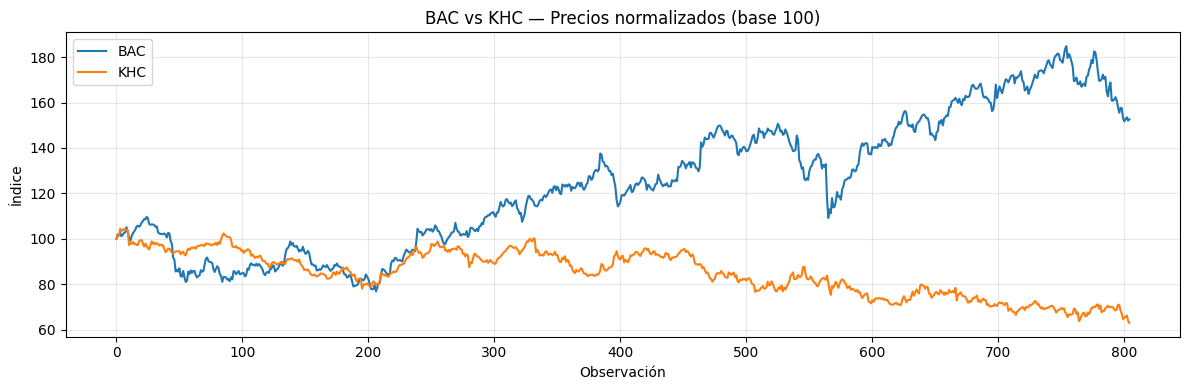

In [19]:
min_len = min(len(bac_d), len(khc_d))
coint_df = pd.DataFrame({
    'BAC': bac_d['Close'].values[:min_len],
    'KHC': khc_d['Close'].values[:min_len]
}).dropna()

result = coint_johansen(coint_df, det_order=0, k_ar_diff=1)

print("Prueba de cointegración de Johansen — BAC vs KHC")
print(f"{'':5} {'Estadístico traza':>20} {'VC 90%':>10} {'VC 95%':>10} {'VC 99%':>10}")
for i in range(len(result.lr1)):
    sig = "✅ Cointegradas (95%)" if result.lr1[i] > result.cvt[i, 1] else "— Sin cointegración"
    print(f"r≤{i}  {result.lr1[i]:>20.4f} {result.cvt[i,0]:>10.4f} {result.cvt[i,1]:>10.4f} {result.cvt[i,2]:>10.4f}  {sig}")

plt.figure(figsize=(12, 4))
(coint_df / coint_df.iloc[0] * 100).plot(ax=plt.gca())
plt.title('BAC vs KHC — Precios normalizados (base 100)')
plt.ylabel('Índice'); plt.xlabel('Observación'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

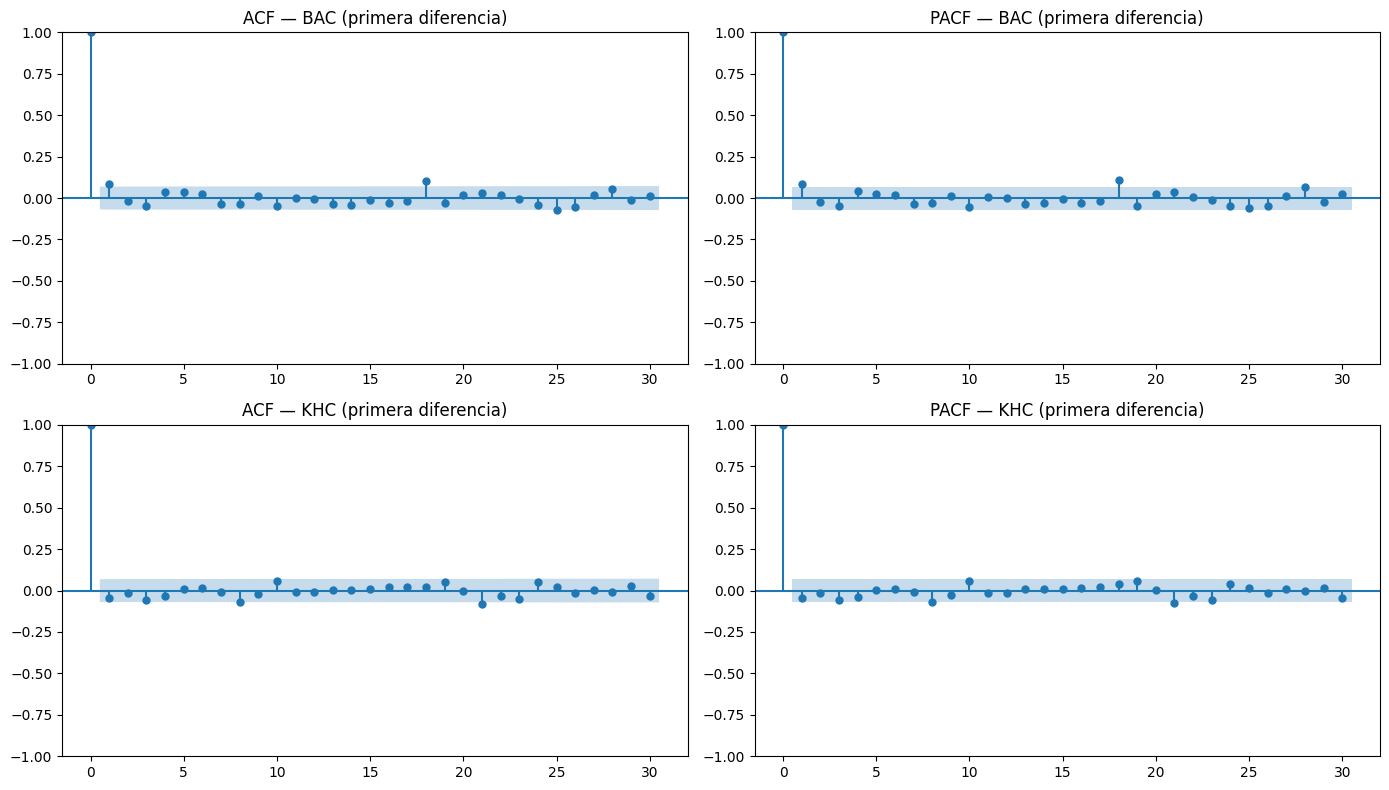

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
bac_diff = bac_d['Close'].diff().dropna()
khc_diff = khc_d['Close'].diff().dropna()

plot_acf(bac_diff,  lags=30, ax=axes[0,0], title='ACF — BAC (primera diferencia)')
plot_pacf(bac_diff, lags=30, ax=axes[0,1], title='PACF — BAC (primera diferencia)')
plot_acf(khc_diff,  lags=30, ax=axes[1,0], title='ACF — KHC (primera diferencia)')
plot_pacf(khc_diff, lags=30, ax=axes[1,1], title='PACF — KHC (primera diferencia)')
plt.tight_layout(); plt.show()

Ajustando ARIMA óptimo para BAC (puede tardar ~1 min)...
Mejor orden ARIMA: (0, 1, 1)

=== FORECAST NUMÉRICO — BAC, próximos 14 días hábiles ===
           Fecha  Precio predicho (USD)  Límite inferior (95%)  Límite superior (95%)
2026-03-20 (Fri)                  47.03                  45.94                  48.12
2026-03-23 (Mon)                  47.03                  45.97                  48.09
2026-03-24 (Tue)                  47.03                  45.99                  48.07
2026-03-25 (Wed)                  47.03                  46.00                  48.06
2026-03-26 (Thu)                  47.03                  46.01                  48.05
2026-03-27 (Fri)                  47.03                  46.01                  48.05
2026-03-30 (Mon)                  47.03                  46.01                  48.04
2026-03-31 (Tue)                  47.03                  46.02                  48.04
2026-04-01 (Wed)                  47.03                  46.02                  4

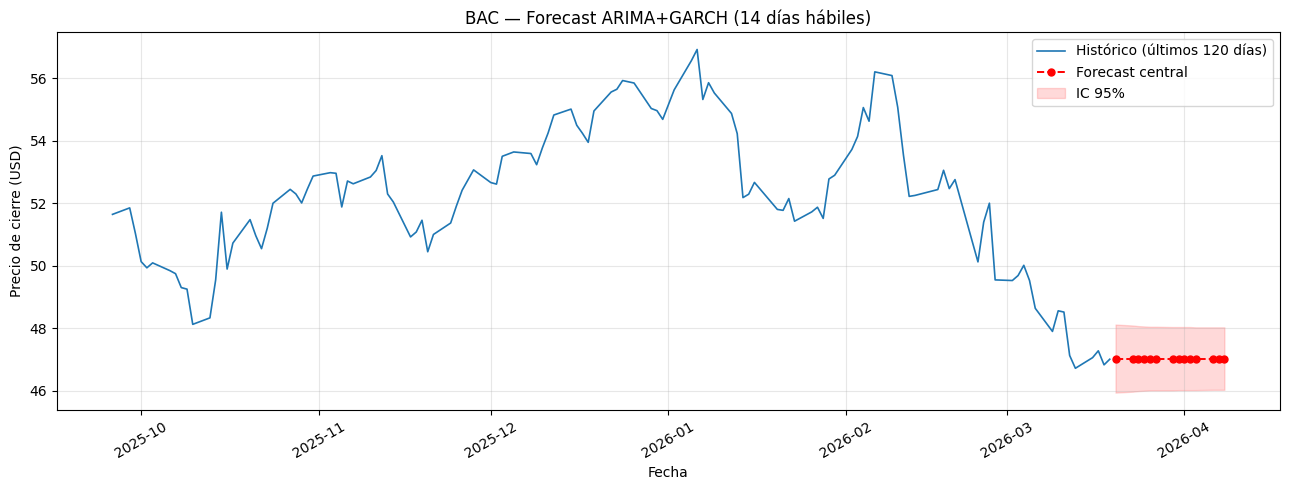

In [21]:
print("Ajustando ARIMA óptimo para BAC (puede tardar ~1 min)...")
arima_model = auto_arima(
    bac_d['Close'],
    seasonal=False, stepwise=True,
    max_p=5, max_q=5, max_d=2,
    information_criterion='aic',
    trace=False,
    error_action='ignore',
    suppress_warnings=True
)
print(f"Mejor orden ARIMA: {arima_model.order}")
arima_model.fit(bac_d['Close'])

last_date    = bac_d.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=14)
current_series = bac_d['Close'].copy()

future_preds, future_lower, future_upper = [], [], []

for i in range(14):
    pred_mean = arima_model.predict(n_periods=1).item()
    resid = arima_model.resid()
    vol = 0.0
    if len(resid) > 30:
        garch = arch_model(resid, mean='Zero', vol='Garch', p=1, q=1, dist='Normal')
        garch_fit = garch.fit(disp='off', show_warning=False)
        vol = np.sqrt(garch_fit.forecast(horizon=1).variance.values[-1, 0])
    future_preds.append(round(pred_mean, 2))
    future_lower.append(round(pred_mean - 1.96 * vol, 2))
    future_upper.append(round(pred_mean + 1.96 * vol, 2))
    current_series[future_dates[i]] = pred_mean
    arima_model.fit(current_series)

forecast_df = pd.DataFrame({
    'Fecha':                   future_dates.strftime('%Y-%m-%d (%a)'),
    'Precio predicho (USD)':   future_preds,
    'Límite inferior (95%)':   future_lower,
    'Límite superior (95%)':   future_upper
})
print("\n=== FORECAST NUMÉRICO — BAC, próximos 14 días hábiles ===")
print(forecast_df.to_string(index=False))

plt.figure(figsize=(13, 5))
plt.plot(bac_d['Close'][-120:], label='Histórico (últimos 120 días)', linewidth=1.2)
plt.plot(future_dates, future_preds, 'r--o', label='Forecast central', linewidth=1.4, markersize=5)
plt.fill_between(future_dates, future_lower, future_upper,
                 color='red', alpha=0.15, label='IC 95%')
plt.title('BAC — Forecast ARIMA+GARCH (14 días hábiles)')
plt.xlabel('Fecha'); plt.ylabel('Precio de cierre (USD)')
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

In [22]:
current_price = bac_d['Close'].iloc[-1]
arr   = np.array(future_preds)
avg_f = arr.mean(); std_f = arr.std()
max_f = arr.max();  min_f = arr.min()
up    = max_f - current_price
down  = current_price - min_f

print(f"Precio actual (último cierre):    ${current_price:.2f}")
print(f"Promedio predicho (14 días):       ${avg_f:.2f}")
print(f"Desviación estándar del forecast:  ${std_f:.2f}")
print(f"Rango predicho:                    ${min_f:.2f} — ${max_f:.2f}")

print("\n=== SEÑAL DE INVERSIÓN ===")
if up > down:
    signal = "COMPRAR (BUY)" if up > std_f * 1.5 else "MANTENER (HOLD)"
else:
    signal = "VENDER EN CORTO (SHORT)" if down > std_f * 1.5 else "MANTENER (HOLD)"
print(f"Señal: {signal}")

Precio actual (último cierre):    $47.01
Promedio predicho (14 días):       $47.03
Desviación estándar del forecast:  $0.00
Rango predicho:                    $47.03 — $47.03

=== SEÑAL DE INVERSIÓN ===
Señal: COMPRAR (BUY)



 GARCH(1,1) — BAC
  omega      = 0.098889
  alpha[1]   = 0.1048   (efecto ARCH)
  beta[1]    = 0.8777   (persistencia)
  alpha+beta = 0.9825  (< 1 → estacionario)
  AIC = 20111.32  |  BIC = 20137.19

 GARCH(1,1) — JPM
  omega      = 0.077072
  alpha[1]   = 0.1022   (efecto ARCH)
  beta[1]    = 0.8788   (persistencia)
  alpha+beta = 0.9809  (< 1 → estacionario)
  AIC = 18594.99  |  BIC = 18620.87

 GARCH(1,1) — PLD
  omega      = 0.050289
  alpha[1]   = 0.0938   (efecto ARCH)
  beta[1]    = 0.8936   (persistencia)
  alpha+beta = 0.9874  (< 1 → estacionario)
  AIC = 18572.25  |  BIC = 18598.13

 GARCH(1,1) — KHC
  omega      = 0.779931
  alpha[1]   = 0.1270   (efecto ARCH)
  beta[1]    = 0.5936   (persistencia)
  alpha+beta = 0.7206  (< 1 → estacionario)
  AIC = 10158.05  |  BIC = 10181.64


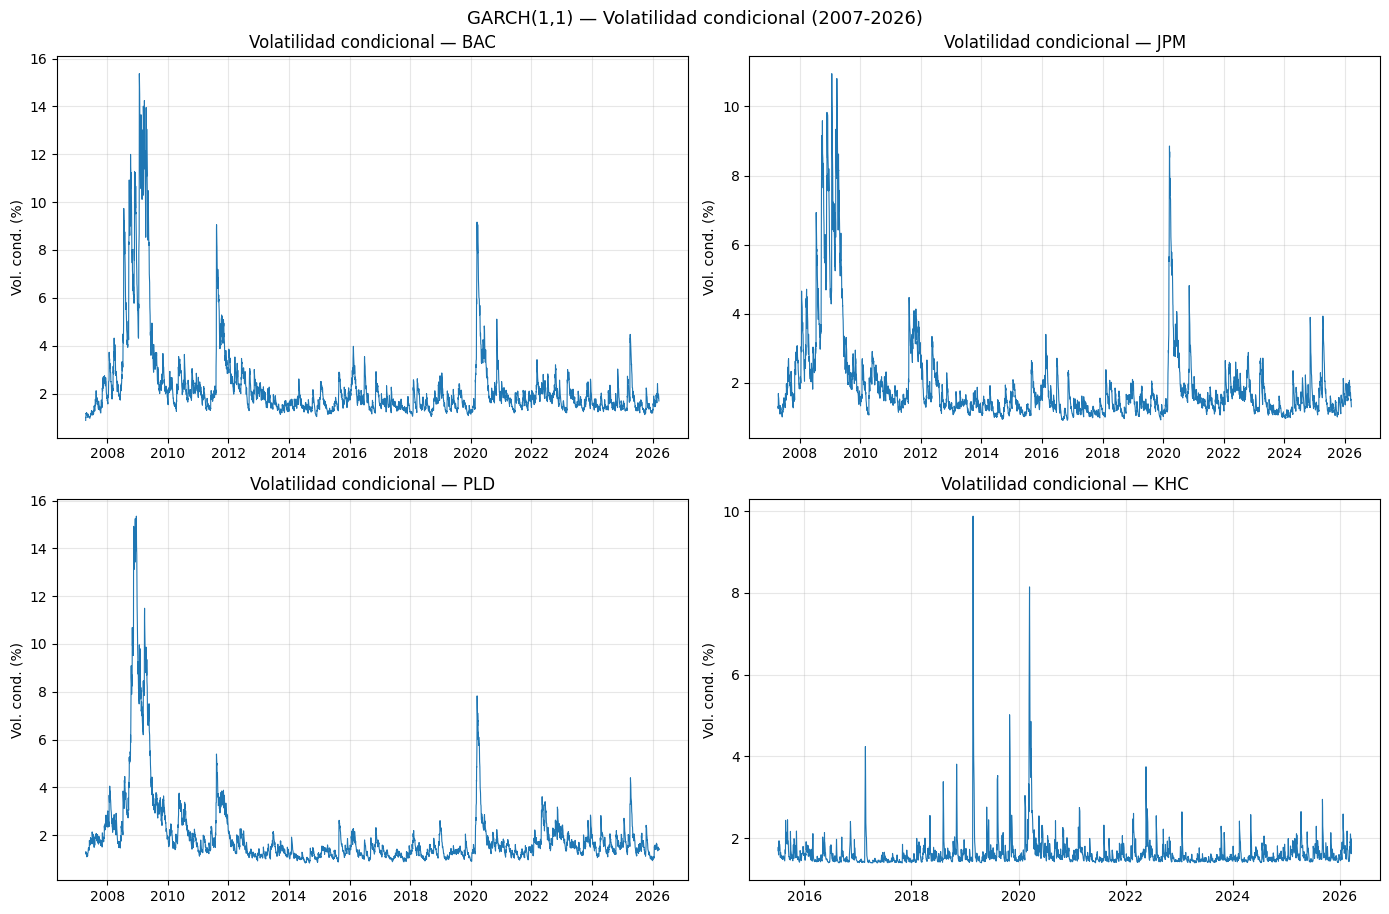

In [23]:
tickers_garch = ['BAC', 'JPM', 'PLD', 'KHC']
garch_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, ticker in enumerate(tickers_garch):
    df_g = yf.download(ticker, start='2007-04-13', end='2026-03-20',
                       progress=False, auto_adjust=True)
    if isinstance(df_g.columns, pd.MultiIndex):
        df_g.columns = df_g.columns.droplevel(1)

    returns = 100 * df_g['Close'].pct_change().dropna()
    gm  = arch_model(returns, mean='Constant', vol='Garch', p=1, q=1, dist='Normal')
    res = gm.fit(disp='off', show_warning=False)
    garch_results[ticker] = res

    print(f"\n{'='*55}")
    print(f" GARCH(1,1) — {ticker}")
    print(f"{'='*55}")
    print(f"  omega      = {res.params['omega']:.6f}")
    print(f"  alpha[1]   = {res.params['alpha[1]']:.4f}   (efecto ARCH)")
    print(f"  beta[1]    = {res.params['beta[1]']:.4f}   (persistencia)")
    print(f"  alpha+beta = {res.params['alpha[1]']+res.params['beta[1]']:.4f}  (< 1 → estacionario)")
    print(f"  AIC = {res.aic:.2f}  |  BIC = {res.bic:.2f}")

    axes[idx].plot(res.conditional_volatility, linewidth=0.8)
    axes[idx].set_title(f'Volatilidad condicional — {ticker}')
    axes[idx].set_ylabel('Vol. cond. (%)'); axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('GARCH(1,1) — Volatilidad condicional (2007-2026)', y=1.01, fontsize=13)
plt.show()

In [24]:
print("\n=== FORECAST DE VOLATILIDAD — próximos 10 días hábiles ===\n")
print(f"{'Día':<5}", end="")
for t in tickers_garch:
    print(f"  {t:>8}", end="")
print()
print("-" * 45)

horizons = 10
all_forecasts = {t: garch_results[t].forecast(horizon=horizons).variance.iloc[-1]
                 for t in tickers_garch}

for h in range(horizons):
    print(f"t+{h+1:<2}", end="")
    for t in tickers_garch:
        print(f"  {np.sqrt(all_forecasts[t].iloc[h]):>8.4f}%", end="")
    print()

print("\n(Desviación estándar condicional diaria en %)")


=== FORECAST DE VOLATILIDAD — próximos 10 días hábiles ===

Día         BAC       JPM       PLD       KHC
---------------------------------------------
t+1     1.6194%    1.2601%    1.3597%    1.8288%
t+2     1.6357%    1.2785%    1.3696%    1.7861%
t+3     1.6516%    1.2963%    1.3794%    1.7546%
t+4     1.6670%    1.3136%    1.3889%    1.7316%
t+5     1.6820%    1.3303%    1.3982%    1.7148%
t+6     1.6966%    1.3465%    1.4074%    1.7026%
t+7     1.7109%    1.3622%    1.4164%    1.6938%
t+8     1.7247%    1.3774%    1.4252%    1.6874%
t+9     1.7383%    1.3921%    1.4338%    1.6828%
t+10    1.7514%    1.4065%    1.4423%    1.6794%

(Desviación estándar condicional diaria en %)


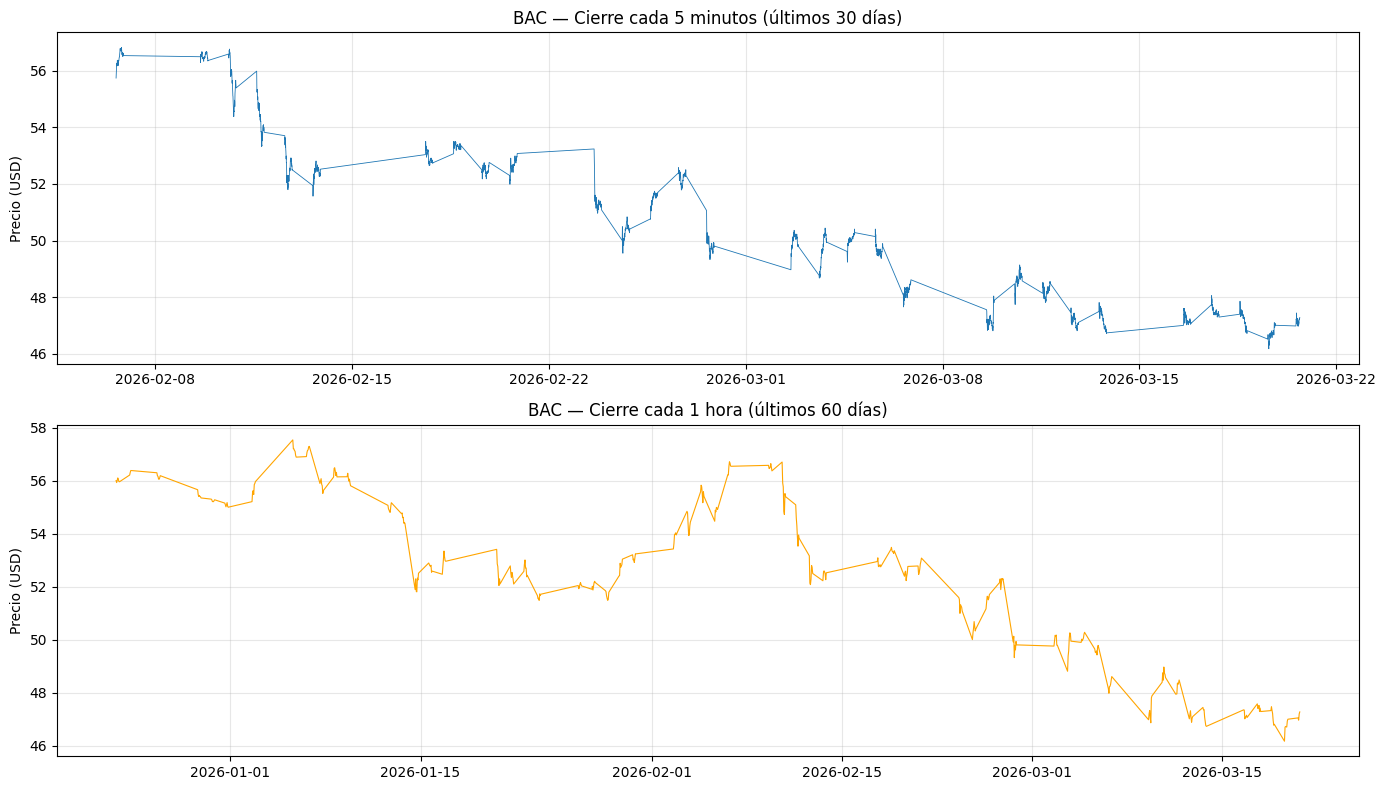

Ajustando ARIMA sobre serie horaria (BAC 1h)...
Mejor ARIMA 1h: (0, 1, 0)

Forecast BAC — próximas 12 horas:
  h+01: $47.28
  h+02: $47.28
  h+03: $47.28
  h+04: $47.28
  h+05: $47.28
  h+06: $47.28
  h+07: $47.28
  h+08: $47.28
  h+09: $47.28
  h+10: $47.28
  h+11: $47.28
  h+12: $47.28


In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(bac_5m['Close'], linewidth=0.6)
axes[0].set_title('BAC — Cierre cada 5 minutos (últimos 30 días)')
axes[0].set_ylabel('Precio (USD)'); axes[0].grid(True, alpha=0.3)

axes[1].plot(bac_1h['Close'], linewidth=0.8, color='orange')
axes[1].set_title('BAC — Cierre cada 1 hora (últimos 60 días)')
axes[1].set_ylabel('Precio (USD)'); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print("Ajustando ARIMA sobre serie horaria (BAC 1h)...")
arima_1h = auto_arima(
    bac_1h['Close'].dropna(),
    seasonal=False, stepwise=True,
    max_p=4, max_q=4, max_d=2,
    information_criterion='aic',
    trace=False, error_action='ignore', suppress_warnings=True
)
print(f"Mejor ARIMA 1h: {arima_1h.order}")

fc_1h = arima_1h.predict(n_periods=12)
print("\nForecast BAC — próximas 12 horas:")
for i, v in enumerate(fc_1h, 1):
    print(f"  h+{i:02d}: ${v:.2f}")